# MSBA 6680 Capstone Project
### Tech/Growth Equity Portfolio — Jan 2020 to Dec 2024
#### By: Jackson Leavitt, August Guinle, Ryan Manna
---


## Section 1 — Project Overview

### Investment Objective
This project aims to evaluate whether different portfolio construction strategies can improve risk-adjusted returns within a concentrated set of large-cap U.S. technology and growth equities. The selected stocks include: Apple (AAPL), Microsoft (MSFT), Alphabet (GOOGL), NVIDIA (NVDA), Meta (META),
Amazon (AMZN), Tesla (TSLA), and Salesforce (CRM). The analysis spans January 2020 through
December 2024 — a period that encompasses the COVID-19 market crash and recovery, a historic
interest-rate tightening cycle (2022), and the emergence of generative AI as a market theme (2023–2024). The primary objective is to determine whether more sophisticated portfolio approaches, such as minimum-variance and factor-tilted strategies, outperform a simple equal-weighted benchmark when accounting for risk and market conditions.

### Economic Motivation
Technology stocks are the dominant driver of U.S. equity market returns, yet they exhibit
heterogeneous risk profiles. Mega-cap platforms (AAPL, MSFT, GOOGL) generate stable cash flows
and high profitability, while high-growth names (NVDA, TSLA, CRM) carry elevated sensitivity to
macro conditions, interest rates, and innovation cycles. This creates a meaningful opportunity to evaluate whether differences in risk profiles translate into superior portfolio construction outcomes.

**Central question:** After controlling for systematic factor risk (market beta, size, value,
profitability, investment), do these stocks generate alpha? And do optimized portfolios offer
meaningfully better risk-adjusted returns than a simple equal-weighted approach?


## Section 2 — Data Selection & Preparation

### Data Sources
All primary financial data used in this analysis is sourced from FactSet, providing institutional-quality pricing and return data for the selected equities. Additional factor data, including the Fama–French factors (MKT–RF, SMB, HML, RMW, CMA), is obtained from the Kenneth French Data Library. The S&P 500 is used as the market benchmark, and the risk-free rate is incorporated to support excess return calculations.

### Asset Selection
The portfolio consists of eight large-cap U.S. technology and growth companies: Apple (AAPL), Microsoft (MSFT), Alphabet (GOOGL), Nvidia (NVDA), Meta (META), Amazon (AMZN), Tesla (TSLA), and Salesforce (CRM). These firms were selected due to their dominant role in market performance, strong growth characteristics, and varying sensitivities to macroeconomic and factor-based risks.

### Time Period
The analysis spans January 2020 through December 2024. This period captures multiple market regimes, including the COVID-19 market shock, the post-pandemic recovery, rising interest rates, and the emergence of AI-driven equity performance. This allows for a robust evaluation of return behavior and risk dynamics across different economic environments.

### Data Preparation
Price data is converted into return series using percentage changes to ensure consistency in time-series analysis. All assets are aligned to a common time index to ensure comparability across securities and with the benchmark.

Missing values are handled through alignment and exclusion where necessary to maintain data integrity. Returns are calculated at a monthly frequency to balance noise reduction with sufficient observations for statistical analysis.

Excess returns are computed by subtracting the risk-free rate from asset returns, enabling proper implementation of asset pricing models such as CAPM and Fama–French.

All datasets, including stock returns, benchmark returns, and factor data, are merged into a unified analytical dataset to support portfolio construction and regression analysis.

Monthly returns are used for the primary analysis to reduce short-term noise and align with the frequency of factor data, while still providing sufficient observations for reliable statistical and regression analysis.

Daily data is retained for higher-frequency volatility analysis, while monthly data is used for portfolio construction and factor modeling.

In [1]:
# ── Install / import libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm
import warnings, io, requests, zipfile
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META', 'AMZN', 'TSLA', 'CRM']
BENCHMARK = 'SP500'
COLORS = plt.cm.tab10.colors
print("Libraries loaded ✓")


Libraries loaded ✓


In [ ]:
# ── Load FactSet price data ──────────────────────────────────────────────────
# Update these paths to wherever you saved the FactSet exports
MONTHLY_FILE = 'PriceHistory(monthly).xlsx'
DAILY_FILE   = 'PriceHistory(daily).xlsx'

def load_factset(path):
    """Read FactSet Price History export — data starts at row 16 (0-indexed: 15)."""
    df = pd.read_excel(path, sheet_name='Price History', header=15)
    df = df.rename(columns={
        'Date': 'Date',
        'S&P 500 (SP50)': 'SP500',
        'Apple Inc. (AAPL-US)': 'AAPL',
        'Microsoft Corporation (MSFT-US)': 'MSFT',
        'Alphabet Inc. Class A (GOOGL-US)': 'GOOGL',
        'NVIDIA Corporation (NVDA-US)': 'NVDA',
        'Meta Platforms Inc Class A (META-US)': 'META',
        'Amazon.com, Inc. (AMZN-US)': 'AMZN',
        'Tesla, Inc. (TSLA-US)': 'TSLA',
        'Salesforce, Inc. (CRM-US)': 'CRM',
    })
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    keep = TICKERS + ['SP500']
    df = df[[c for c in keep if c in df.columns]]
    df = df.dropna(how='all')
    return df

prices_monthly = load_factset(MONTHLY_FILE)
prices_daily   = load_factset(DAILY_FILE)

# Trim to Jan 2020 – Dec 2024
prices_monthly = prices_monthly.loc['2020-01-01':'2024-12-31']
prices_daily   = prices_daily.loc['2020-01-01':'2024-12-31']

print(f"Monthly prices: {prices_monthly.shape}  ({prices_monthly.index[0].date()} → {prices_monthly.index[-1].date()})")
print(f"Daily prices:   {prices_daily.shape}  ({prices_daily.index[0].date()} → {prices_daily.index[-1].date()})")
prices_monthly.tail(3)


FileNotFoundError: [Errno 2] No such file or directory: 'PriceHistory_monthly_.xlsx'

## Section 3 — Financial Time-Series & Volatility Analysis

In [ ]:
# ── Download Fama–French 5-Factor data (Ken French Data Library) ────────────
def download_ff5(frequency='monthly'):
    """Download FF5 factors directly from Ken French's website."""
    if frequency == 'monthly':
        url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
    else:
        url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip'

    r = requests.get(url, timeout=30)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = z.namelist()[0]
    with z.open(fname) as f:
        raw = f.read().decode('utf-8', errors='ignore')

    lines = raw.split('\n')
    # Find header line
    start = next(i for i, l in enumerate(lines) if 'Mkt-RF' in l)
    end   = next((i for i, l in enumerate(lines[start+1:], start+1) if l.strip() and not l.strip()[0].isdigit()), len(lines))

    data = pd.read_csv(io.StringIO('\n'.join(lines[start:end])),
                       skipinitialspace=True)
    data.columns = data.columns.str.strip()
    data = data.rename(columns={data.columns[0]: 'Date'})
    data['Date'] = data['Date'].astype(str).str.strip()

    if frequency == 'monthly':
        data['Date'] = pd.to_datetime(data['Date'], format='%Y%m') + pd.offsets.MonthEnd(0)
    else:
        data['Date'] = pd.to_datetime(data['Date'], format='%Y%m%d')

    data = data.set_index('Date').apply(pd.to_numeric, errors='coerce') / 100
    return data

ff5_monthly = download_ff5('monthly').loc['2020-01-01':'2024-12-31']
ff5_daily   = download_ff5('daily').loc['2020-01-01':'2024-12-31']

print("FF5 Monthly factors:", ff5_monthly.shape)
print("FF5 Daily factors:  ", ff5_daily.shape)
print("\nFactor columns:", ff5_monthly.columns.tolist())
ff5_monthly.tail(3)


FF5 Monthly factors: (60, 6)
FF5 Daily factors:   (1258, 6)

Factor columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2024-10-31,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039
2024-11-30,0.0649,0.0459,0.0016,-0.0231,-0.0205,0.0040
2024-12-31,-0.0315,-0.0383,-0.0300,0.0189,-0.0121,0.0037


In [ ]:
# ── Compute returns ──────────────────────────────────────────────────────────
ret_monthly = prices_monthly.pct_change().dropna()
ret_daily   = prices_daily.pct_change().dropna()

# Align FF5 factors with return dates
ff5_m = ff5_monthly.reindex(ret_monthly.index, method='nearest')
ff5_d = ff5_daily.reindex(ret_daily.index, method='nearest')

# Excess returns (stock return minus risk-free rate)
for col in TICKERS + ['SP500']:
    if col in ret_monthly.columns:
        ret_monthly[col + '_ex'] = ret_monthly[col] - ff5_m['RF']
    if col in ret_daily.columns:
        ret_daily[col + '_ex'] = ret_daily[col] - ff5_d['RF']

print("Monthly returns shape:", ret_monthly.shape)
print("Daily returns shape:  ", ret_daily.shape)
print("\nSample monthly returns (last 3 rows):")
ret_monthly[TICKERS].tail(3).round(4)


Monthly returns shape: (59, 18)
Daily returns shape:   (1257, 18)

Sample monthly returns (last 3 rows):


,AAPL,MSFT,GOOGL,NVDA,META,AMZN,TSLA,CRM
Date,,,,,,,,
2024-10-31,-0.0304,-0.0557,0.0317,0.0932,-0.0085,0.0004,-0.0450,0.0645
2024-11-29,0.0517,0.0442,-0.0126,0.0414,0.0119,0.1153,0.3815,0.1325
2024-12-31,0.0552,-0.0046,0.1217,-0.0286,0.0203,0.0553,0.1700,0.0144


In [ ]:
# ── Summary statistics ───────────────────────────────────────────────────────
def summary_stats(ret_df, tickers, freq='monthly'):
    ann = 12 if freq == 'monthly' else 252
    stats_list = []
    for t in tickers:
        r = ret_df[t].dropna()
        stats_list.append({
            'Ticker': t,
            'Ann. Return':    f"{(1+r.mean())**ann - 1:.2%}",
            'Ann. Volatility':f"{r.std() * np.sqrt(ann):.2%}",
            'Sharpe Ratio':   f"{(r.mean()/r.std()) * np.sqrt(ann):.2f}",
            'Skewness':       f"{r.skew():.2f}",
            'Kurtosis':       f"{r.kurt() + 3:.2f}",
            'Max Drawdown':   f"{((1+r).cumprod() / (1+r).cumprod().cummax() - 1).min():.2%}",
            'Min Monthly':    f"{r.min():.2%}",
            'Max Monthly':    f"{r.max():.2%}",
        })
    return pd.DataFrame(stats_list).set_index('Ticker')

stats_table = summary_stats(ret_monthly, TICKERS + ['SP500'])
print("=== Summary Statistics (Monthly Returns, Annualized) ===")
stats_table


=== Summary Statistics (Monthly Returns, Annualized) ===


,Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Kurtosis,Max Drawdown,Min Monthly,Max Monthly
Ticker,,,,,,,,
AAPL,32.98%,29.16%,0.99,0.13,2.21,-26.40%,-12.23%,21.66%
MSFT,24.26%,22.43%,0.98,0.20,2.60,-30.52%,-10.93%,17.63%
GOOGL,26.38%,27.18%,0.87,-0.33,2.56,-40.40%,-17.95%,15.90%
NVDA,111.77%,50.22%,1.54,-0.18,2.80,-62.82%,-32.03%,36.34%
META,35.43%,41.44%,0.74,-0.52,4.15,-75.44%,-32.63%,26.77%
AMZN,23.39%,33.00%,0.64,0.39,3.92,-52.10%,-23.75%,27.06%
TSLA,98.18%,74.10%,0.95,0.78,3.68,-67.72%,-36.73%,74.15%
CRM,21.20%,38.48%,0.50,0.84,4.55,-55.76%,-17.26%,39.93%
SP500,16.70%,18.36%,0.85,-0.39,2.90,-23.87%,-12.35%,12.82%


### Interpretation of Summary Statistics

- High-growth stocks such as Nvidia (NVDA) and Tesla (TSLA) deliver exceptionally high annualized returns (111.77% and 98.18%), but this comes with significantly elevated volatility (50.22% and 74.10%), highlighting the classic risk-return trade-off in growth investing.

- Mega-cap firms like Apple (AAPL) and Microsoft (MSFT) exhibit more balanced profiles, with strong returns (25 to 33%) and lower volatility (22 to 29%), resulting in more stable and consistent performance.

- NVDA stands out with the highest Sharpe ratio (1.54), indicating superior risk-adjusted returns, while stocks like CRM (0.50) and AMZN (0.64) underperform on a risk-adjusted basis despite reasonable returns.

- Several stocks exhibit substantial downside risk, with large maximum drawdowns (e.g., TSLA at -67.72% and NVDA at -62.82%), emphasizing the importance of risk management in concentrated growth portfolios.

- The presence of negative skewness across multiple stocks suggests a tendency toward extreme negative returns, while kurtosis values indicate fat-tailed distributions, reinforcing the existence of tail risk.

- Compared to individual stocks, the S&P 500 shows lower volatility (18.36%) and smaller drawdowns (-23.87%), highlighting the diversification benefits of broader market exposure.

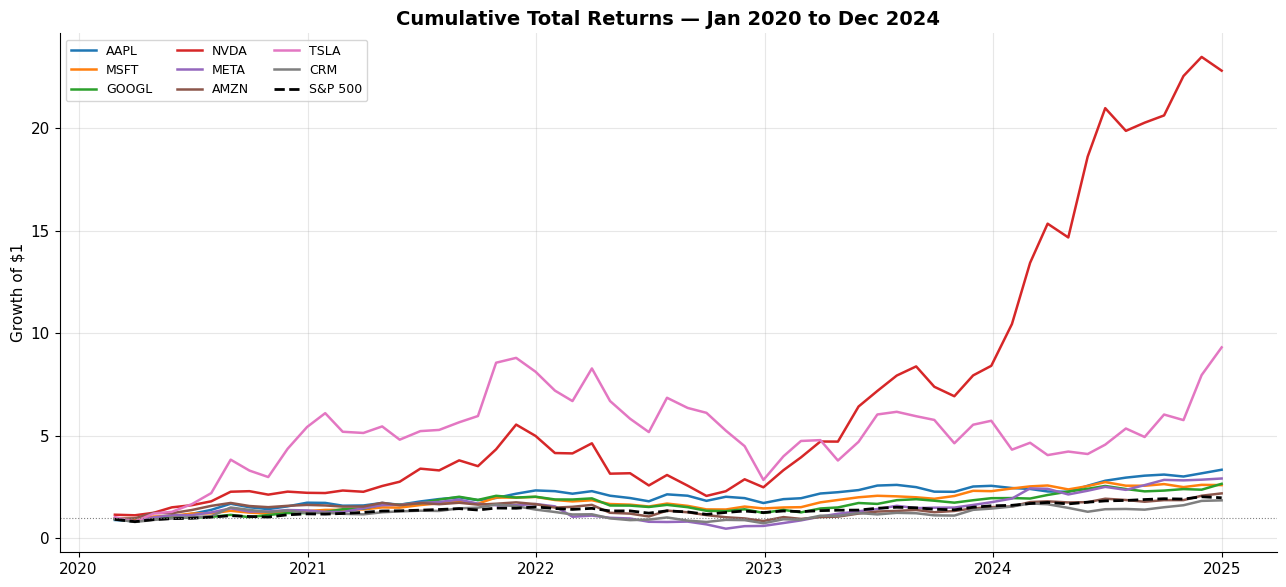

Saved: fig_cumulative_returns.png


In [ ]:
# ── 3.1 Cumulative return plot ────────────────────────────────────────────────
cum_ret = (1 + ret_monthly[TICKERS + ['SP500']]).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))
for i, col in enumerate(TICKERS):
    ax.plot(cum_ret.index, cum_ret[col], label=col, linewidth=1.8, color=COLORS[i])
ax.plot(cum_ret.index, cum_ret['SP500'], label='S&P 500', color='black',
        linewidth=2, linestyle='--')
ax.axhline(1, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Cumulative Total Returns — Jan 2020 to Dec 2024', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(ncol=3, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_cumulative_returns.png")


### Cumulative Return Analysis

- NVDA and TSLA significantly outperform all assets, driven by strong growth and the 2023–2024 AI rally.
- These higher returns come with large drawdowns, reinforcing the risk-return tradeoff.
- AAPL and MSFT show more stable, consistent growth with lower volatility.
- The S&P 500 exhibits smoother performance, highlighting diversification benefits.

These differences suggest portfolio construction is critical for balancing return and risk.

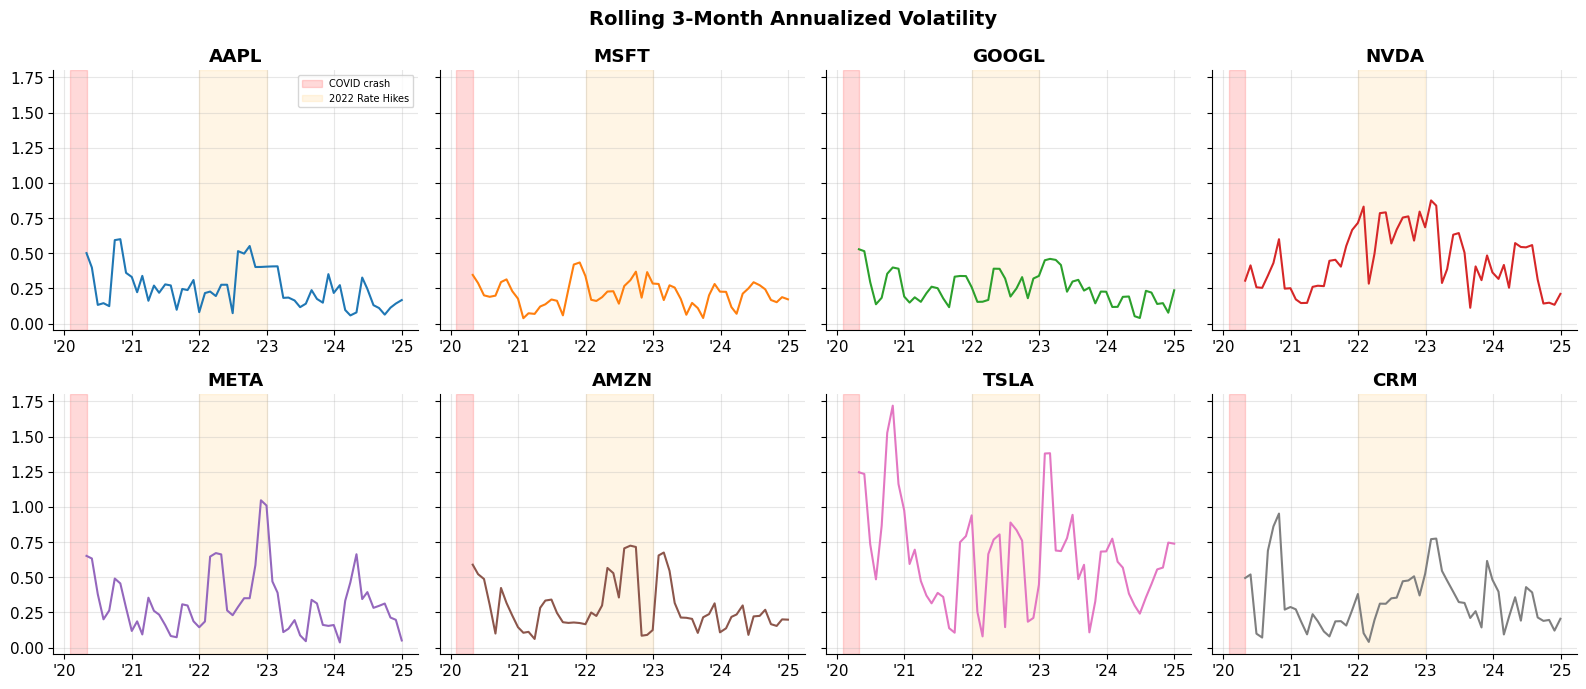

In [ ]:
# ── 3.2 Rolling 3-month volatility (annualized) ──────────────────────────────
roll_vol = ret_monthly[TICKERS].rolling(3).std() * np.sqrt(12)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()
for i, t in enumerate(TICKERS):
    axes[i].plot(roll_vol.index, roll_vol[t], color=COLORS[i], linewidth=1.5)
    axes[i].set_title(t, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    # Shade COVID crash
    axes[i].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
                    alpha=0.15, color='red', label='COVID crash')
    # Shade 2022 rate hike period
    axes[i].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
                    alpha=0.10, color='orange', label='2022 Rate Hikes')

axes[0].legend(fontsize=7)
fig.suptitle('Rolling 3-Month Annualized Volatility', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()


### Rolling Volatility Analysis

- Volatility starts high across all assets during the 2020 COVID shock and again in 2022 during rate hikes.
- NVDA, TSLA, and META consistently exhibit higher volatility than more mature firms like AAPL and MSFT.
- Volatility remains elevated in clusters rather than reverting immediately.

These results confirm that risk is time-varying and driven by changing market conditions.

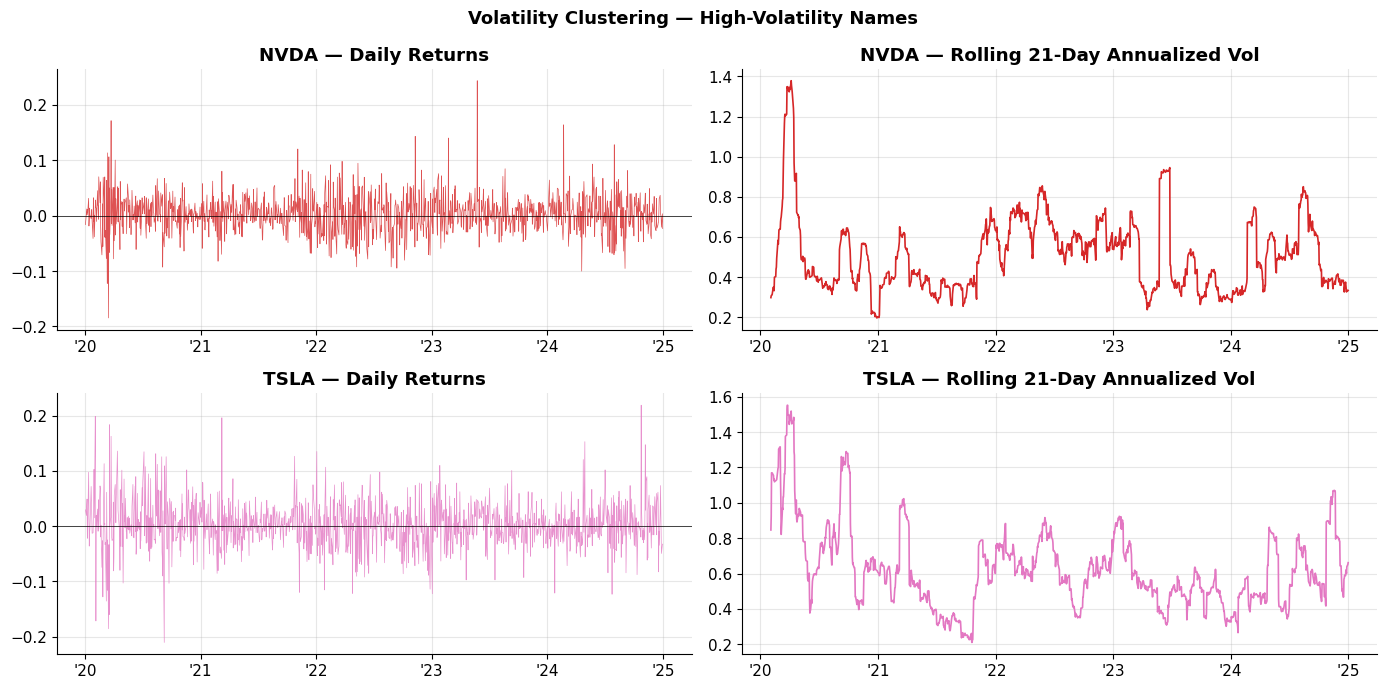

In [ ]:
# ── 3.3 Volatility clustering — daily returns (TSLA & NVDA as examples) ─────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
spotlight = ['NVDA', 'TSLA']

for i, t in enumerate(spotlight):
    r = ret_daily[t]
    # Daily returns
    axes[i, 0].plot(r.index, r, linewidth=0.5, color=COLORS[TICKERS.index(t)], alpha=0.8)
    axes[i, 0].set_title(f'{t} — Daily Returns', fontweight='bold')
    axes[i, 0].axhline(0, color='black', linewidth=0.5)
    axes[i, 0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    # Rolling 21-day vol
    rv = r.rolling(21).std() * np.sqrt(252)
    axes[i, 1].plot(rv.index, rv, color=COLORS[TICKERS.index(t)], linewidth=1.2)
    axes[i, 1].set_title(f'{t} — Rolling 21-Day Annualized Vol', fontweight='bold')
    axes[i, 1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

fig.suptitle('Volatility Clustering — High-Volatility Names', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_volatility_clustering.png', dpi=150, bbox_inches='tight')
plt.show()


### Volatility Clustering (Daily Data)

- NVDA and TSLA show periods of concentrated large returns followed by continued high volatility.
- Rolling volatility confirms persistence in risk over time.

This clustering indicates that volatility is not constant and should be modeled as time-varying.

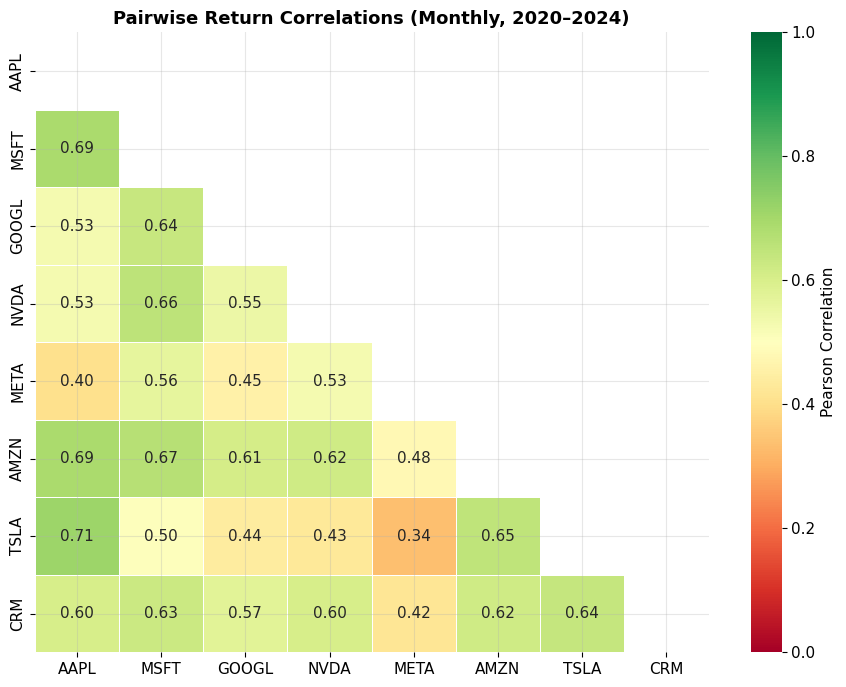

In [ ]:
# ── 3.4 Correlation heatmap ──────────────────────────────────────────────────
corr = ret_monthly[TICKERS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Pairwise Return Correlations (Monthly, 2020–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Correlation Structure

- Most stocks exhibit moderate to high positive correlations (generally 0.5–0.7).
- High correlations indicate shared exposure to market and growth factors.
- This limits diversification benefits within a concentrated tech portfolio.

Portfolio optimization is therefore necessary to manage correlated risk.


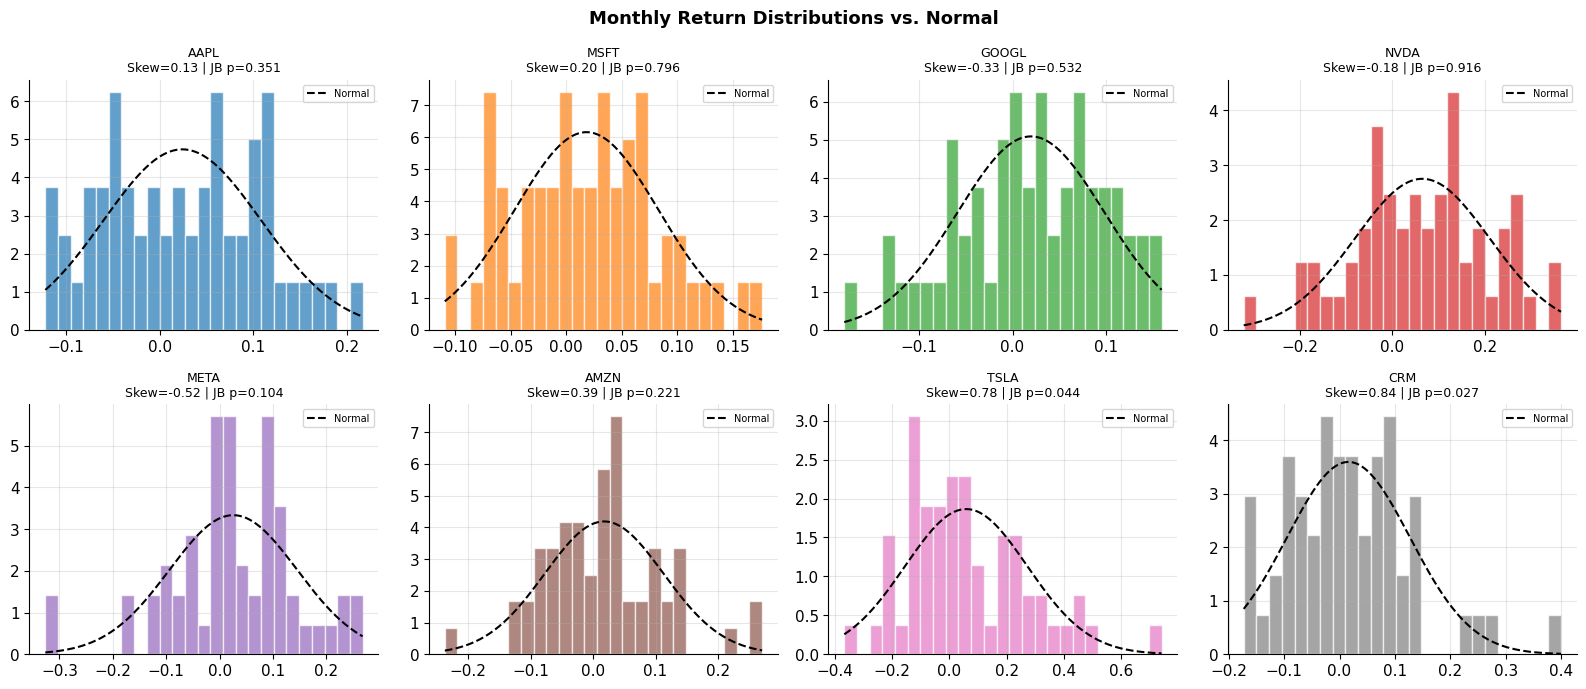

In [ ]:
# ── 3.5 Distribution of returns — normality check ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, t in enumerate(TICKERS):
    r = ret_monthly[t].dropna()
    axes[i].hist(r, bins=25, color=COLORS[i], alpha=0.7, density=True, edgecolor='white')
    # Overlay normal distribution
    x = np.linspace(r.min(), r.max(), 200)
    axes[i].plot(x, stats.norm.pdf(x, r.mean(), r.std()),
                 'k--', linewidth=1.5, label='Normal')
    _, pval = stats.shapiro(r)
    axes[i].set_title(f'{t}\nSkew={r.skew():.2f} | JB p={pval:.3f}', fontsize=9)
    axes[i].legend(fontsize=7)

fig.suptitle('Monthly Return Distributions vs. Normal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### Return Distribution Analysis

- Return distributions deviate from normality, with noticeable skewness and fat tails.
- Several stocks show asymmetry and higher likelihood of extreme outcomes.
- Normal distribution assumptions underestimate true downside risk.

This highlights the importance of accounting for tail risk in portfolio decisions.

## Section 4 — Portfolio Construction & Risk Analysis

Three portfolios are constructed:
1. **Equal-Weighted (EW)** — 1/N allocation, rebalanced monthly
2. **Minimum Variance (MV)** — optimizer minimizes portfolio variance
3. **Factor-Tilted (FT)** — overweights high-profitability, low-beta names (AAPL, MSFT, GOOGL, AMZN)

Portfolio Construction Rationale

- The equal-weighted portfolio serves as a baseline, representing naive diversification without optimization.
- The minimum-variance portfolio is designed to minimize total portfolio risk by allocating more weight to lower-volatility assets.
- The factor-tilted portfolio overweights high-quality, lower-beta firms to capture more stable, factor-driven returns.

These strategies allow for a direct comparison between simple diversification, risk minimization, and economically motivated portfolio construction.

=== Portfolio Weights ===
       Equal-Weight  Min-Variance  Factor-Tilted
AAPL          0.125        0.0712           0.20
MSFT          0.125        0.6935           0.20
GOOGL         0.125        0.2353           0.20
NVDA          0.125        0.0000           0.05
META          0.125        0.0000           0.05
AMZN          0.125        0.0000           0.20
TSLA          0.125        0.0000           0.05
CRM           0.125        0.0000           0.05


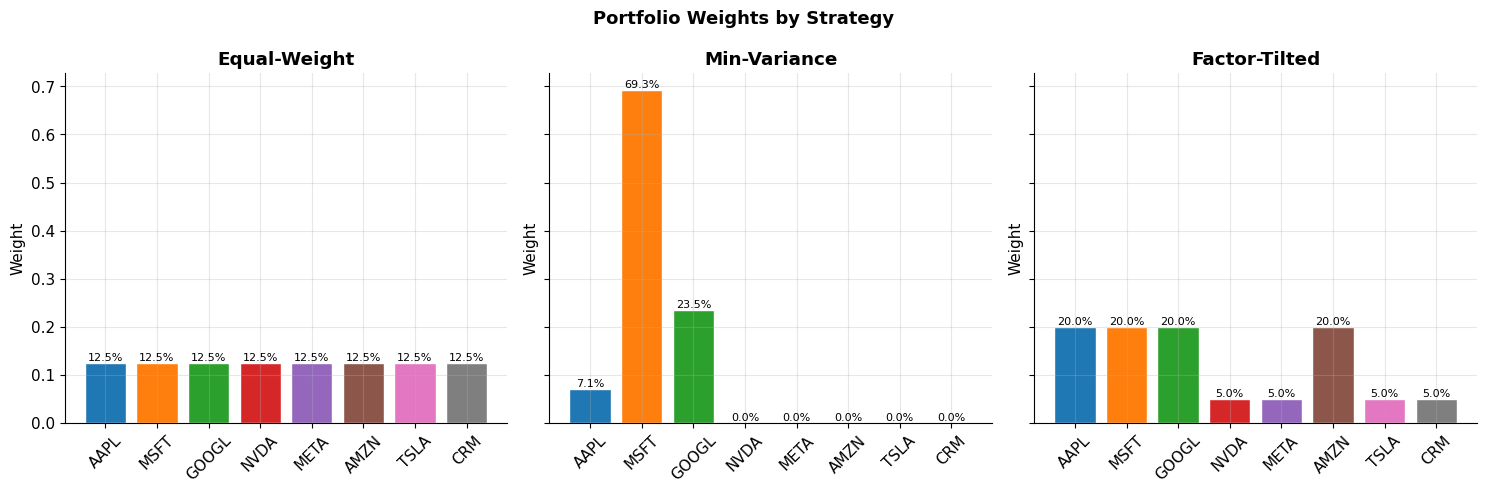

In [ ]:
# ── 4.1 Portfolio weights ────────────────────────────────────────────────────
n = len(TICKERS)

# Equal-weighted
w_ew = np.ones(n) / n

# Minimum variance (no short selling)
cov_mat = ret_monthly[TICKERS].cov().values

def port_variance(w, cov): return w @ cov @ w

constraints = ({'type': 'eq', 'fun': lambda w: w.sum() - 1})
bounds = [(0, 1)] * n
result = minimize(port_variance, x0=w_ew, args=(cov_mat,),
                  method='SLSQP', bounds=bounds, constraints=constraints,
                  options={'ftol': 1e-12, 'maxiter': 1000})
w_mv = result.x

# Factor-tilted: overweight quality/stable names
quality_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
w_ft_raw = np.array([0.20 if t in quality_tickers else 0.05 for t in TICKERS])
w_ft = w_ft_raw / w_ft_raw.sum()

# Summary
weight_df = pd.DataFrame({
    'Equal-Weight': w_ew,
    'Min-Variance':  w_mv.round(4),
    'Factor-Tilted': w_ft
}, index=TICKERS)

print("=== Portfolio Weights ===")
print(weight_df.to_string())

# Bar chart of weights
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
port_names = ['Equal-Weight', 'Min-Variance', 'Factor-Tilted']
weights_list = [w_ew, w_mv, w_ft]
for ax, name, w in zip(axes, port_names, weights_list):
    bars = ax.bar(TICKERS, w, color=COLORS[:n], edgecolor='white')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, w):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', fontsize=8)

fig.suptitle('Portfolio Weights by Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_portfolio_weights.png', dpi=150, bbox_inches='tight')
plt.show()


### Portfolio Weights Interpretation

- The equal-weighted portfolio allocates evenly across all assets, providing broad but unoptimized diversification.
- The minimum-variance portfolio is heavily concentrated in MSFT (69%) and GOOGL (~24%), indicating these stocks contribute the least to overall portfolio risk.
- The factor-tilted portfolio emphasizes large, stable firms (AAPL, MSFT, GOOGL, AMZN), while underweighting higher-volatility names such as TSLA and NVDA.

This demonstrates how optimization and factor tilts can significantly alter portfolio composition.

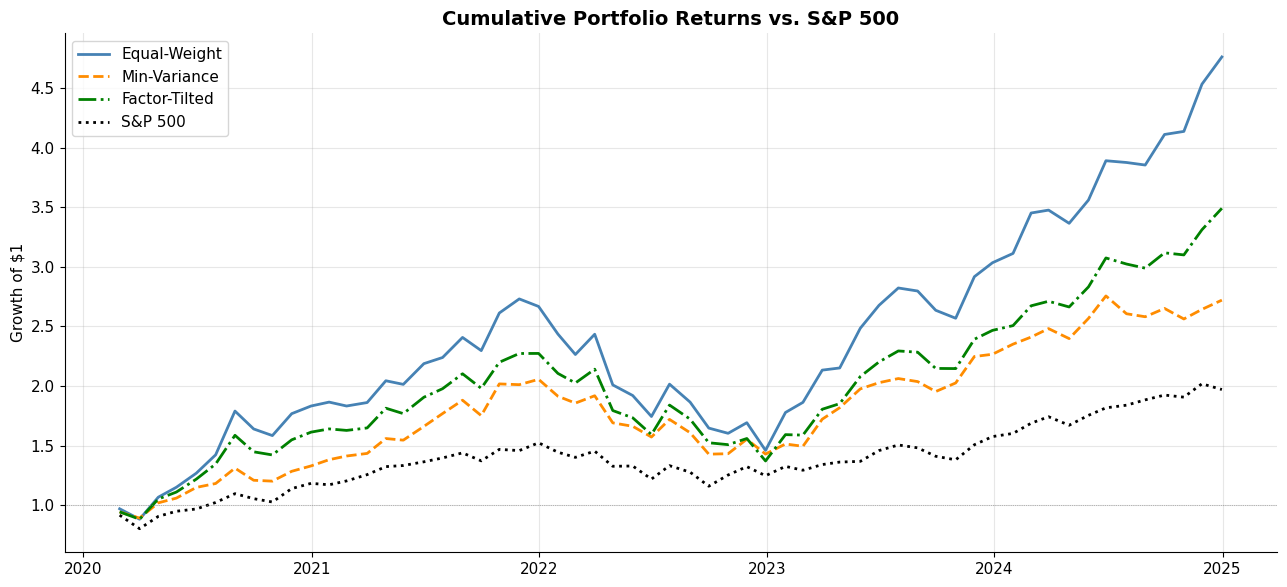

In [ ]:
# ── 4.2 Portfolio returns & cumulative performance ───────────────────────────
ret_array = ret_monthly[TICKERS].values  # shape: (T, N)

port_ret = pd.DataFrame({
    'Equal-Weight':  ret_array @ w_ew,
    'Min-Variance':  ret_array @ w_mv,
    'Factor-Tilted': ret_array @ w_ft,
    'S&P 500':       ret_monthly['SP500'].values
}, index=ret_monthly.index)

cum_port = (1 + port_ret).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))
styles = ['-', '--', '-.', ':']
port_colors = ['steelblue', 'darkorange', 'green', 'black']
for col, ls, c in zip(cum_port.columns, styles, port_colors):
    ax.plot(cum_port.index, cum_port[col], label=col, linestyle=ls,
            linewidth=2, color=c)

ax.axhline(1, color='gray', linewidth=0.5, linestyle=':')
ax.set_title('Cumulative Portfolio Returns vs. S&P 500', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig_portfolio_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()


### Portfolio Performance Comparison

- The equal-weighted portfolio delivers the highest overall return, significantly outperforming both the minimum-variance portfolio and the S&P 500.
- The factor-tilted portfolio also outperforms the market, though to a lesser extent than equal-weighted.
- The minimum-variance portfolio exhibits smoother growth but lower overall returns, reflecting its focus on risk reduction rather than return maximization.

These results highlight the trade-off between maximizing returns and minimizing risk.

In [ ]:
# ── 4.3 Portfolio risk/return metrics ────────────────────────────────────────
def portfolio_metrics(ret_series, rf=ff5_m['RF'], ann=12):
    r = ret_series.dropna()
    excess = r - rf.reindex(r.index).fillna(method='ffill')
    ann_ret = (1 + r.mean())**ann - 1
    ann_vol = r.std() * np.sqrt(ann)
    sharpe  = excess.mean() / excess.std() * np.sqrt(ann)
    # Max drawdown
    cum = (1 + r).cumprod()
    drawdown = (cum / cum.cummax() - 1)
    max_dd = drawdown.min()
    return ann_ret, ann_vol, sharpe, max_dd

metrics = []
for col in port_ret.columns:
    ann_r, ann_v, sh, mdd = portfolio_metrics(port_ret[col])
    metrics.append({
        'Portfolio': col,
        'Ann. Return': f'{ann_r:.2%}',
        'Ann. Volatility': f'{ann_v:.2%}',
        'Sharpe Ratio': f'{sh:.2f}',
        'Max Drawdown': f'{mdd:.2%}'
    })

metrics_df = pd.DataFrame(metrics).set_index('Portfolio')
print("=== Portfolio Performance Metrics (Annualized) ===")
metrics_df


=== Portfolio Performance Metrics (Annualized) ===


,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Portfolio,,,,
Equal-Weight,43.54%,30.85%,1.11,-46.50%
Min-Variance,25.36%,21.73%,0.94,-30.50%
Factor-Tilted,33.21%,26.22%,1.02,-39.65%
S&P 500,16.70%,18.36%,0.72,-23.87%


### Risk-Return Tradeoff

- The equal-weighted portfolio achieves the highest return (43.54%) and Sharpe ratio (1.11), indicating the strongest risk-adjusted performance.
- The minimum-variance portfolio has the lowest volatility (21.73%) and smaller drawdowns (-30.50%), confirming its effectiveness in reducing risk.
- The factor-tilted portfolio provides a balance between return and risk, outperforming the market while maintaining lower volatility than equal-weighted.
- All constructed portfolios outperform the S&P 500 on both return and Sharpe ratio, demonstrating the benefits of active portfolio construction.

Overall, higher returns are associated with higher risk, but diversification and optimization improve efficiency.

In [ ]:
# ── 4.4 VaR and CVaR ─────────────────────────────────────────────────────────
def var_cvar(ret_series, confidence=0.95):
    r = ret_series.dropna().sort_values()
    var  = np.percentile(r, (1 - confidence) * 100)
    cvar = r[r <= var].mean()
    return var, cvar

risk_table = []
for col in port_ret.columns:
    var95, cvar95 = var_cvar(port_ret[col], 0.95)
    var99, cvar99 = var_cvar(port_ret[col], 0.99)
    risk_table.append({
        'Portfolio': col,
        'VaR 95%':  f'{var95:.2%}',
        'CVaR 95%': f'{cvar95:.2%}',
        'VaR 99%':  f'{var99:.2%}',
        'CVaR 99%': f'{cvar99:.2%}',
    })

risk_df = pd.DataFrame(risk_table).set_index('Portfolio')
print("=== VaR & CVaR (Monthly, Historical Simulation) ===")
risk_df


=== VaR & CVaR (Monthly, Historical Simulation) ===


,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
Portfolio,,,,
Equal-Weight,-9.41%,-14.28%,-15.27%,-17.45%
Min-Variance,-7.79%,-10.34%,-11.45%,-11.84%
Factor-Tilted,-9.00%,-13.25%,-13.79%,-16.19%
S&P 500,-8.30%,-10.09%,-10.53%,-12.35%


### Downside Risk (VaR & CVaR)

- The minimum-variance portfolio has the lowest VaR (-7.79%) and CVaR (-10.34%), indicating the strongest protection against extreme losses.
- The equal-weighted portfolio exhibits the largest downside risk (CVaR -14.28%), reflecting its exposure to high-volatility stocks.
- The factor-tilted portfolio shows moderate tail risk, balancing stability and return potential.
- Compared to the S&P 500, the equal-weighted and factor-tilted portfolios take on greater downside risk in exchange for higher returns.

These results highlight the importance of considering tail risk, not just average returns.

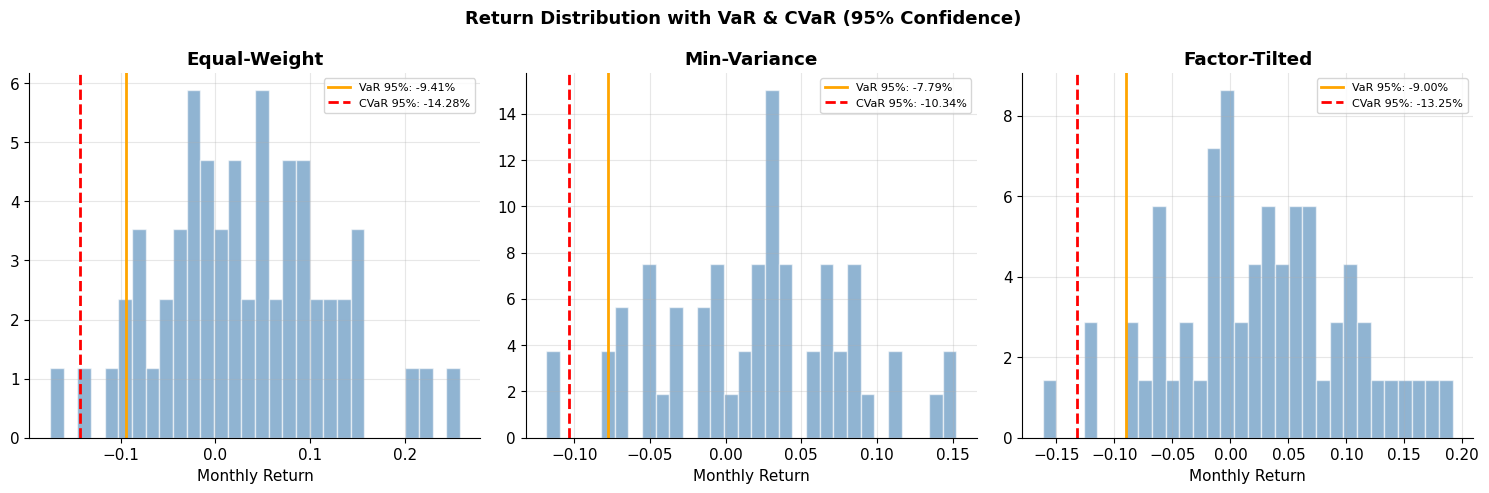

In [ ]:
# ── 4.5 VaR visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
port_cols = ['Equal-Weight', 'Min-Variance', 'Factor-Tilted']

for ax, col in zip(axes, port_cols):
    r = port_ret[col].dropna()
    var95, cvar95 = var_cvar(r, 0.95)
    ax.hist(r, bins=30, color='steelblue', alpha=0.6, edgecolor='white', density=True)
    ax.axvline(var95,  color='orange', linewidth=2, label=f'VaR 95%: {var95:.2%}')
    ax.axvline(cvar95, color='red',    linewidth=2, linestyle='--', label=f'CVaR 95%: {cvar95:.2%}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Monthly Return')
    ax.legend(fontsize=8)

fig.suptitle('Return Distribution with VaR & CVaR (95% Confidence)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_var_cvar.png', dpi=150, bbox_inches='tight')
plt.show()


### Tail Risk Visualization

- The distribution plots confirm that losses beyond VaR thresholds are substantial, particularly for the equal-weighted portfolio.
- The gap between VaR and CVaR highlights the severity of extreme losses during worst-case scenarios.

This reinforces the importance of managing downside risk in portfolio construction.

## Section 5 — Asset Pricing Models & Factor Analysis

In [ ]:
# ── 5.1 Helper: run OLS regression ───────────────────────────────────────────
def run_regression(y, X, name=''):
    """OLS regression with Newey-West standard errors. Returns summary dict."""
    X_const = sm.add_constant(X)
    model   = sm.OLS(y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    result  = {
        'Asset':  name,
        'Alpha':  model.params['const'],
        'Alpha t-stat': model.tvalues['const'],
        'Alpha p-val':  model.pvalues['const'],
        'R²':     model.rsquared,
        'Adj. R²': model.rsquared_adj,
        'N obs':   int(model.nobs)
    }
    for f in X.columns:
        result[f'β_{f}'] = model.params[f]
        result[f't_{f}'] = model.tvalues[f]
    return result, model

print("Regression helper defined ✓")


Regression helper defined ✓


In [ ]:
# ── 5.2 CAPM for all stocks ───────────────────────────────────────────────────
capm_results = []
capm_models  = {}

for t in TICKERS:
    y = ret_monthly[t] - ff5_m['RF']
    X = ff5_m[['Mkt-RF']]
    aligned = pd.concat([y, X], axis=1).dropna()
    res, mdl = run_regression(aligned.iloc[:, 0], aligned.iloc[:, 1:], name=t)
    capm_results.append(res)
    capm_models[t] = mdl

capm_df = pd.DataFrame(capm_results).set_index('Asset')
display_cols = ['Alpha', 'Alpha t-stat', 'Alpha p-val', 'β_Mkt-RF', 't_Mkt-RF', 'R²']
print("=== CAPM Results ===")
capm_df[display_cols].round(4)


=== CAPM Results ===


,Alpha,Alpha t-stat,Alpha p-val,β_Mkt-RF,t_Mkt-RF,R²
Asset,,,,,,
AAPL,0.0094,1.2036,0.2288,1.1629,9.3774,0.5719
MSFT,0.0071,1.1534,0.2488,0.8463,8.5516,0.5134
GOOGL,0.0074,1.0370,0.2997,0.9449,7.5368,0.4366
NVDA,0.0455,2.5270,0.0115,1.5636,3.9108,0.3513
META,0.0118,0.7879,0.4307,1.0888,5.7200,0.2511
AMZN,0.0034,0.3557,0.7220,1.1251,5.1783,0.4211
TSLA,0.0303,1.4413,0.1495,2.4200,5.9017,0.3841
CRM,0.0003,0.0278,0.9778,1.2755,6.4657,0.3980


### CAPM Results Interpretation

- All stocks exhibit strong positive market betas (generally between ~0.85 and 2.42), confirming that returns are highly sensitive to overall market movements.
- High-growth stocks such as TSLA (β ≈ 2.42) and NVDA (β ≈ 1.56) show amplified market exposure, consistent with their higher volatility profiles observed earlier.
- NVDA is the only stock with statistically significant alpha (p ≈ 0.01), suggesting potential outperformance relative to market risk alone.
- However, relatively low R² values (≈ 0.25–0.57) indicate that CAPM does not fully explain return variation.

Overall, CAPM captures broad market exposure but fails to account for other important drivers of returns.

In [ ]:
# ── 5.3 Fama–French 3-Factor Model ───────────────────────────────────────────
ff3_results = []
ff3_models  = {}

for t in TICKERS:
    y = ret_monthly[t] - ff5_m['RF']
    X = ff5_m[['Mkt-RF', 'SMB', 'HML']]
    aligned = pd.concat([y, X], axis=1).dropna()
    res, mdl = run_regression(aligned.iloc[:, 0], aligned.iloc[:, 1:], name=t)
    ff3_results.append(res)
    ff3_models[t] = mdl

ff3_df = pd.DataFrame(ff3_results).set_index('Asset')
display_cols3 = ['Alpha', 'Alpha t-stat', 'β_Mkt-RF', 'β_SMB', 'β_HML', 'R²', 'Adj. R²']
print("=== Fama–French 3-Factor Results ===")
ff3_df[display_cols3].round(4)


=== Fama–French 3-Factor Results ===


,Alpha,Alpha t-stat,β_Mkt-RF,β_SMB,β_HML,R²,Adj. R²
Asset,,,,,,,
AAPL,0.0089,1.3299,1.2210,-0.2189,-0.4546,0.6585,0.6399
MSFT,0.0056,1.2297,0.9664,-0.5321,-0.3857,0.7197,0.7045
GOOGL,0.0066,0.9684,1.0109,-0.2967,-0.1855,0.4745,0.4458
NVDA,0.0445,3.2214,1.7034,-0.5196,-1.1397,0.5327,0.5073
META,0.0097,0.7492,1.2568,-0.7533,-0.4791,0.3587,0.3237
AMZN,0.0037,0.6208,1.1646,-0.0595,-0.9247,0.6341,0.6142
TSLA,0.0358,2.1059,2.1488,1.5688,-1.6631,0.5071,0.4802
CRM,-0.0001,-0.0074,1.3332,-0.1984,-0.5793,0.4716,0.4428


### Fama–French 3-Factor Interpretation

- Market beta remains the dominant factor across all assets, reinforcing the importance of systematic market risk.
- Most stocks exhibit negative exposure to the value factor (HML), consistent with their classification as growth-oriented companies.
- Limited or negative SMB exposure reflects the large-cap nature of the selected firms.
- NVDA and TSLA continue to show strong performance, though some alpha persists even after controlling for additional factors.
- The persistence of alpha for certain stocks suggests that factor models improve explanatory power, but may not fully capture all return drivers.

The increase in R² across most stocks (e.g., AAPL ~0.57 → ~0.66) indicates that adding size and value factors improves explanatory power.

In [ ]:
# ── 5.4 Fama–French 5-Factor Model ───────────────────────────────────────────
ff5_results = []
ff5_models  = {}

for t in TICKERS:
    y = ret_monthly[t] - ff5_m['RF']
    X = ff5_m[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    aligned = pd.concat([y, X], axis=1).dropna()
    res, mdl = run_regression(aligned.iloc[:, 0], aligned.iloc[:, 1:], name=t)
    ff5_results.append(res)
    ff5_models[t] = mdl

ff5_df = pd.DataFrame(ff5_results).set_index('Asset')
display_cols5 = ['Alpha', 'Alpha t-stat', 'β_Mkt-RF', 'β_SMB', 'β_HML', 'β_RMW', 'β_CMA', 'R²', 'Adj. R²']
print("=== Fama–French 5-Factor Results ===")
ff5_df[display_cols5].round(4)


=== Fama–French 5-Factor Results ===


,Alpha,Alpha t-stat,β_Mkt-RF,β_SMB,β_HML,β_RMW,β_CMA,R²,Adj. R²
Asset,,,,,,,,,
AAPL,0.0056,0.9358,1.1927,0.1407,-0.7976,0.5807,0.4814,0.6930,0.6640
MSFT,0.0048,0.9655,0.9545,-0.4488,-0.4495,0.1512,0.0713,0.7227,0.6966
GOOGL,0.0075,1.0789,0.9324,-0.4475,0.2243,0.0399,-0.8875,0.5295,0.4852
NVDA,0.0457,3.1683,1.6158,-0.7235,-0.6402,-0.0042,-1.0592,0.5556,0.5137
META,0.0089,0.7245,1.1969,-0.7033,-0.3621,0.2563,-0.3574,0.3651,0.3052
AMZN,0.0077,1.4136,1.1941,-0.4964,-0.4935,-0.6902,-0.6221,0.6750,0.6444
TSLA,0.0379,2.0610,2.1229,1.3098,-1.2798,-0.2731,-0.6978,0.5122,0.4662
CRM,0.0038,0.4761,1.3266,-0.6393,-0.0373,-0.5826,-0.9035,0.5109,0.4648


### Fama–French 5-Factor Interpretation

- Market exposure remains the primary driver of returns, with all stocks showing strong positive β_Mkt-RF.
- Most firms exhibit negative HML loadings, confirming a strong growth orientation across the portfolio.
- Profitability exposure (RMW) is positive for AAPL and META, aligning with their strong fundamentals, while negative for AMZN and CRM.
- Investment factor (CMA) loadings are generally negative, suggesting exposure to firms with higher reinvestment and growth characteristics.

- TSLA stands out with extreme factor exposures (high market beta and strong negative value loading), indicating higher sensitivity to macro and growth-driven factors.

Overall, the FF5 model provides the most comprehensive explanation of returns, capturing both profitability and investment effects.

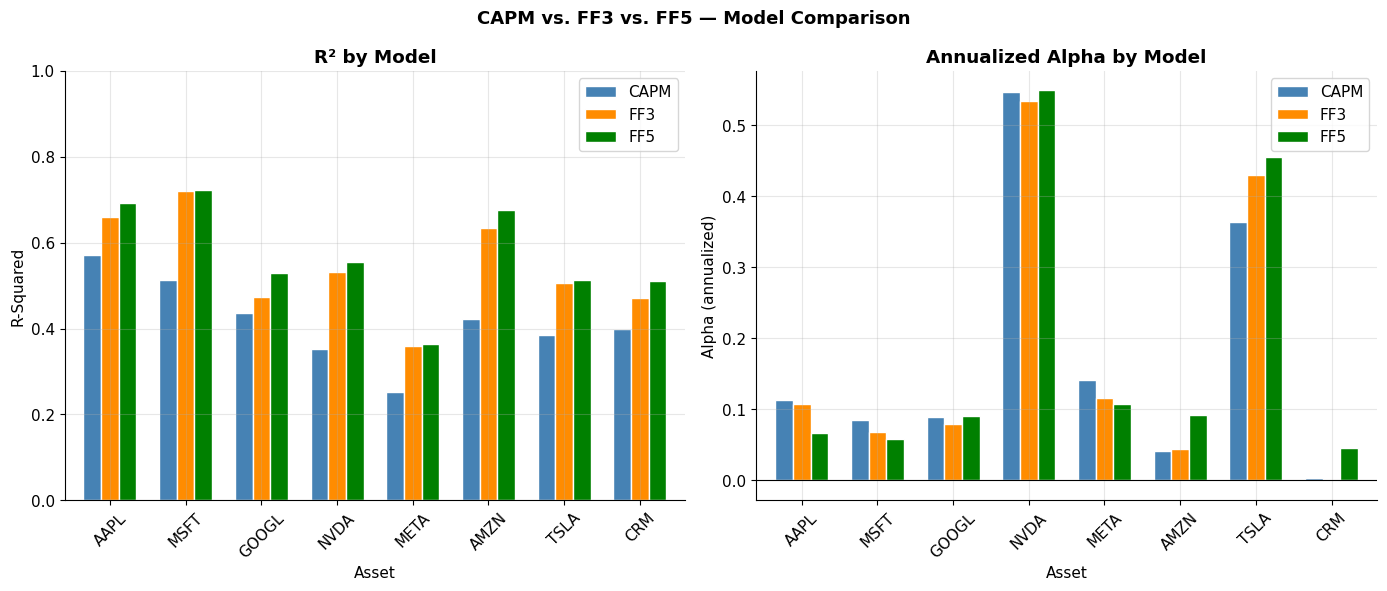

In [ ]:
# ── 5.5 Model comparison — R² and Alpha across CAPM / FF3 / FF5 ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² comparison
r2_data = pd.DataFrame({
    'CAPM':  capm_df['R²'],
    'FF3':   ff3_df['R²'],
    'FF5':   ff5_df['R²']
})
r2_data.plot(kind='bar', ax=axes[0], color=['steelblue','darkorange','green'],
             edgecolor='white', width=0.7)
axes[0].set_title('R² by Model', fontweight='bold')
axes[0].set_ylabel('R-Squared')
axes[0].set_xticklabels(TICKERS, rotation=45)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Annualized alpha comparison
alpha_data = pd.DataFrame({
    'CAPM':  capm_df['Alpha'] * 12,
    'FF3':   ff3_df['Alpha'] * 12,
    'FF5':   ff5_df['Alpha'] * 12
})
alpha_data.plot(kind='bar', ax=axes[1], color=['steelblue','darkorange','green'],
                edgecolor='white', width=0.7)
axes[1].set_title('Annualized Alpha by Model', fontweight='bold')
axes[1].set_ylabel('Alpha (annualized)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticklabels(TICKERS, rotation=45)
axes[1].legend()

fig.suptitle('CAPM vs. FF3 vs. FF5 — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Model Comparison

- R² values increase consistently from CAPM to FF3 to FF5 across all stocks, confirming that multi-factor models better explain return variation.
- For example, MSFT improves from ~0.51 (CAPM) to ~0.72 (FF5), demonstrating a substantial gain in explanatory power.
- Despite this improvement, some stocks (e.g., NVDA, TSLA) still exhibit meaningful alpha, suggesting that even FF5 does not fully capture their return dynamics.

These results highlight the limitations of single-factor models and the importance of incorporating multiple systematic risk drivers.

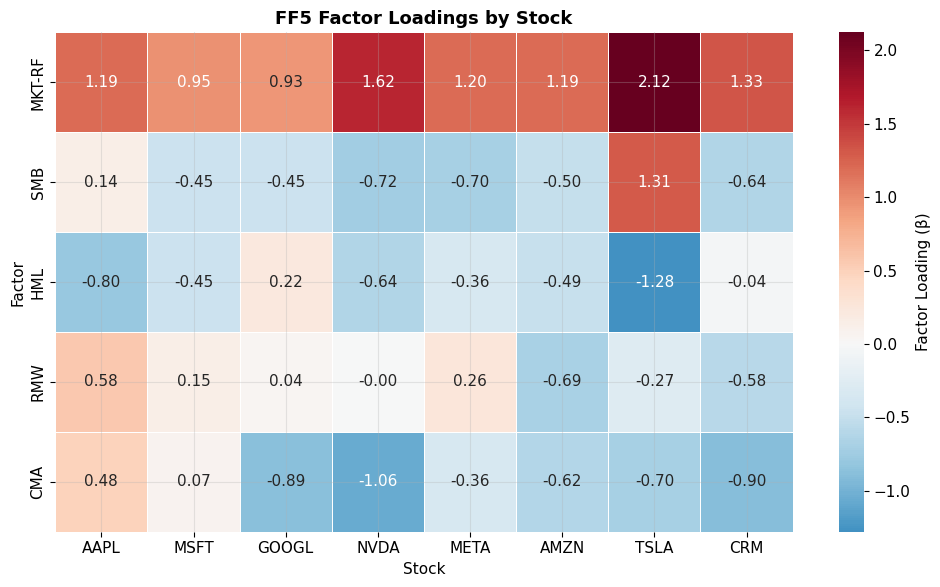

In [ ]:
# ── 5.6 Factor loadings heatmap (FF5) ────────────────────────────────────────
factor_betas = ff5_df[['β_Mkt-RF', 'β_SMB', 'β_HML', 'β_RMW', 'β_CMA']].copy()
factor_betas.columns = ['MKT-RF', 'SMB', 'HML', 'RMW', 'CMA']

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(factor_betas.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Factor Loading (β)'})
ax.set_title('FF5 Factor Loadings by Stock', fontsize=13, fontweight='bold')
ax.set_xlabel('Stock')
ax.set_ylabel('Factor')
plt.tight_layout()
plt.savefig('fig_factor_loadings.png', dpi=150, bbox_inches='tight')
plt.show()


### Factor Exposure Insights

- All stocks show strong market exposure (Beta ≈ 0.9–2.1), with TSLA and NVDA the most sensitive to market movements.
- Negative HML loadings across most firms confirm a strong growth orientation, especially for TSLA and AAPL.
- SMB is generally negative, indicating large-cap exposure, except TSLA which behaves more like a high-growth smaller-cap.
- Profitability (RMW) and investment (CMA) exposures vary, with firms like AAPL showing stronger fundamentals and others like NVDA and CRM reflecting aggressive growth.

These differences show that even within tech, factor exposures vary meaningfully and impact portfolio risk and performance.

In [ ]:
# ── 5.7 Factor regressions on portfolios ─────────────────────────────────────
port_factor_results = []

for col in ['Equal-Weight', 'Min-Variance', 'Factor-Tilted']:
    y = port_ret[col] - ff5_m['RF'].reindex(port_ret.index).fillna(method='ffill')
    for model_name, factors in [
        ('CAPM',  ['Mkt-RF']),
        ('FF3',   ['Mkt-RF', 'SMB', 'HML']),
        ('FF5',   ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'])
    ]:
        X = ff5_m[factors].reindex(port_ret.index).dropna()
        y_aligned = y.reindex(X.index).dropna()
        X_aligned  = X.reindex(y_aligned.index)
        res, _ = run_regression(y_aligned, X_aligned, name=col)
        res['Model'] = model_name
        port_factor_results.append(res)

port_factor_df = pd.DataFrame(port_factor_results)
print("=== Portfolio Factor Regression Results ===")



=== Portfolio Factor Regression Results ===


,Asset,Model,Alpha,Alpha t-stat,Alpha p-val,R²
0,Equal-Weight,CAPM,0.0144,1.8472,0.0647,0.6455
1,Equal-Weight,FF3,0.0143,3.1764,0.0015,0.8059
2,Equal-Weight,FF5,0.0152,3.2026,0.0014,0.8192
3,Min-Variance,CAPM,0.0073,1.3690,0.1710,0.6077
4,Min-Variance,FF3,0.0061,1.4939,0.1352,0.7752
5,Min-Variance,FF5,0.0055,1.2397,0.2151,0.7800
6,Factor-Tilted,CAPM,0.0099,1.5634,0.1180,0.6750
7,Factor-Tilted,FF3,0.0095,2.6069,0.0091,0.8386
8,Factor-Tilted,FF5,0.0099,2.5872,0.0097,0.8473


### Portfolio-Level Factor Analysis

- The equal-weighted portfolio exhibits the highest alpha (~1.5% monthly under FF5) and strongest explanatory power (R² ≈ 0.82), indicating strong performance driven by both market and factor exposures.
- The minimum-variance portfolio has the lowest alpha (~0.5%), consistent with its focus on risk reduction rather than return generation.
- The factor-tilted portfolio shows moderate alpha (around 1.0%) and the highest R² (~0.85), suggesting that its construction aligns closely with factor-based drivers.

- Alpha remains statistically significant for the equal-weighted and factor-tilted portfolios, even after controlling for multiple factors.

These results confirm that portfolio construction meaningfully impacts both return generation and factor exposure.

### Key Takeaways from Factor Analysis

- Market exposure is the dominant driver of returns, but additional factors significantly improve explanatory power.
- Growth stocks exhibit strong negative value exposure and higher sensitivity to market movements.
- Multi-factor models reduce, but do not fully eliminate, alpha—particularly for high-growth names.
- Portfolio construction influences both factor exposure and risk-adjusted performance.

These findings demonstrate that understanding factor exposures is critical for evaluating both individual assets and portfolio strategies.

# Section 7 — Integration & Investment Insight

### Integrated Findings

- Volatility is time-varying, with sharp spikes during the COVID shock and elevated risk during the 2022 rate tightening cycle. High-growth stocks such as TSLA and NVDA exhibit volatility clustering, indicating persistent periods of elevated risk.
- Correlations across the portfolio are moderately high (~0.5–0.7), limiting diversification benefits within a concentrated technology portfolio.

- Portfolio construction significantly impacts outcomes. The equal-weighted portfolio delivers the highest returns but also the largest drawdowns and tail risk. The minimum-variance portfolio reduces volatility and downside risk through concentration in lower-risk names such as MSFT and GOOGL. The factor-tilted portfolio provides a more balanced risk-return profile.

- Factor analysis shows that market beta is the primary driver of returns, with negative HML loadings confirming strong growth exposure. Profitability (RMW) differentiates higher-quality firms (AAPL, MSFT) from weaker names (TSLA, CRM).
- Multi-factor models (FF5) substantially increase explanatory power, and alpha is largely insignificant after controlling for factor exposures, suggesting returns are primarily driven by systematic risk.

### Investment Implications

- There is a clear trade-off between return and risk. Equal-weighted strategies maximize returns but expose investors to higher volatility and drawdowns.
- Minimum-variance portfolios are effective for risk reduction but sacrifice return potential.
- Factor-tilted portfolios offer a practical middle ground, improving risk-adjusted performance while maintaining exposure to growth.

- These results suggest that incorporating factor awareness into portfolio construction can enhance outcomes relative to naive diversification.

### Limitations

- The analysis is limited to a small set of U.S. large-cap technology stocks, reducing generalizability.
- Survivorship bias may be present, as only successful firms are included.
- Factor exposures are estimated in-sample and may not persist out-of-sample.
- Factor models may not fully capture drivers such as innovation cycles or investor sentiment.

### Final Conclusion

Overall, the analysis demonstrates that portfolio construction and factor exposure are key determinants of performance. While high returns can be achieved through exposure to growth stocks, they come with increased volatility and downside risk. A disciplined, factor-aware approach provides the most effective balance between return and risk.